In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from xgboost import XGBRegressor

# Import local modules
import sys
sys.path.insert(0, '.')
from delta_config import get_config, BASE_PATH, VERSION
from delta_data_prep import prepare_full_pipeline, build_stacked_delta_dataset

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

OUTPUT_DIR = 'outputs'

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

In [2]:
# ============================================
# CONFIGURATION - CHANGE THESE VALUES
# ============================================

n_test_years = 5  # Number of last years to use as test set

# Model configurations (model_name, optimize_metric, model_instance)
MODEL_CONFIGS = [
    ('Ridge', 'rmse', Ridge(alpha=1.0)),
    ('Ridge', 'worst_case', Ridge(alpha=1.0)),
    ('XGBoost', 'rmse', XGBRegressor(n_estimators=4, max_depth=1, learning_rate=0.1, random_state=42, verbosity=0)),
    ('XGBoost', 'worst_case', XGBRegressor(n_estimators=4, max_depth=1, learning_rate=0.1, random_state=42, verbosity=0)),
]

print(f"Configuration:")
print(f"  Test years: last {n_test_years} years")
print(f"  Models: {[f'{m[0]}_{m[1]}' for m in MODEL_CONFIGS]}")

Configuration:
  Test years: last 5 years
  Models: ['Ridge_rmse', 'Ridge_worst_case', 'XGBoost_rmse', 'XGBoost_worst_case']


## 2. Load Data and Feature Selection Results

In [3]:
# Load configuration
config = get_config()

# Load base data
print("Loading base data...")
df_base, base_feature_cols, all_target_years = prepare_full_pipeline(BASE_PATH, VERSION, config)
print(f"  Base data shape: {df_base.shape}")
print(f"  Base features: {len(base_feature_cols)}")
print(f"  Available target years: {all_target_years}")

# Determine test years
test_years = sorted(all_target_years)[-n_test_years:]
print(f"\n  Test years: {test_years}")

Loading base data...
LOADING AND IMPUTING BASE DATA
✓ Loaded 773 rows, 42 columns
  Years: 1990 - 2019
  Countries: 57
✓ Target imputation complete. Remaining NaN in Value: 0
⚠ Dropping 3 columns with >50% NaN:
    - Poverty headcount ratio at national poverty lines (% of population) (82.3% NaN)
    - Prevalence tobacco use (70.5% NaN)
    - Total sales of agricultural pesticides (tonnes) (80.9% NaN)
✓ After ffill/bfill: 569 NaN remaining in features
  Applying IterativeImputer for remaining NaN...
✓ After IterativeImputer: 0 NaN remaining
✓ 32 base features identified
✓ Computed deltas for 32 features + incidence
✓ 27 target years available: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(201

In [4]:
# Load feature selection summaries
fs_summary_files = glob.glob(os.path.join(OUTPUT_DIR, 'fs_summary_*.csv'))
fs_summaries = []

for f in fs_summary_files:
    df = pd.read_csv(f)
    fs_summaries.append(df)

fs_summary = pd.concat(fs_summaries, ignore_index=True)

print(f"✓ Loaded {len(fs_summary_files)} per-year summary files")
print(f"Total feature selection runs: {len(fs_summary)}")

# Build features dictionary by (year, selection)
features_by_year_selection = {}
for _, row in fs_summary.iterrows():
    year = int(row['target_year'])
    selection = row['selection']
    features = [f.strip() for f in row['selected_features'].split(' | ')]
    features_by_year_selection[(year, selection)] = features

available_years = sorted(set(k[0] for k in features_by_year_selection.keys()))
print(f"\nFeature selections available for years: {available_years}")

✓ Loaded 26 per-year summary files
Total feature selection runs: 104

Feature selections available for years: [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


## 3. Run Out-of-Sample Tests

In [5]:
# Storage for test results
test_results = []
detailed_predictions = []

print("=" * 80)
print(f"RUNNING OUT-OF-SAMPLE TESTS ON {n_test_years} YEARS")
print("=" * 80)

for test_year in test_years:
    train_year = test_year - 1
    
    print(f"\n{'─' * 60}")
    print(f"Test Year: {test_year} (training on {train_year}, predicting {test_year}→{test_year+1})")
    print(f"{'─' * 60}")
    
    # Check if train_year has feature selection results
    if train_year not in available_years:
        print(f"  ⚠ No feature selection for year {train_year}, skipping")
        continue
    
    # Build datasets for train and test years (with drop_na=False to keep all rows)
    train_df_full, train_features, train_family_map = build_stacked_delta_dataset(
        df_base, base_feature_cols, train_year, drop_na=False
    )
    test_df_full, test_features, test_family_map = build_stacked_delta_dataset(
        df_base, base_feature_cols, test_year, drop_na=False
    )
    
    if train_df_full.empty or test_df_full.empty:
        print(f"  ⚠ Empty dataset for train or test year, skipping")
        continue
    
    # Test each model configuration
    for model_name, metric, model_template in MODEL_CONFIGS:
        selection_key = f"{model_name}_{metric}"
        
        # Get features from previous year's selection (EXACT column names from fs_summary)
        if (train_year, selection_key) not in features_by_year_selection:
            print(f"  ⚠ No {selection_key} selection for year {train_year}")
            continue
        
        selected_features = features_by_year_selection[(train_year, selection_key)]
        
        # Filter to features available in both train and test
        valid_features = [f for f in selected_features 
                        if f in train_df_full.columns and f in test_df_full.columns]
        
        if len(valid_features) == 0:
            print(f"  ⚠ No valid features for {selection_key}")
            continue
        
        # Drop NaN only for the selected features + target
        train_df = train_df_full.dropna(subset=valid_features + ['target']).copy()
        test_df = test_df_full.dropna(subset=valid_features + ['target']).copy()
        
        if train_df.empty or test_df.empty:
            print(f"  ⚠ No complete data after dropping NaN for {selection_key}")
            continue
        
        # Get actual incidence values
        # incidence at test_year (to add to predicted delta)
        test_year_incidence = df_base[df_base['Year'] == test_year][['Country Code', 'Value']].copy()
        test_year_incidence.columns = ['Country Code', 'incidence_at_test_year']
        
        # incidence at test_year+1 (ground truth)
        next_year_incidence = df_base[df_base['Year'] == test_year + 1][['Country Code', 'Value']].copy()
        next_year_incidence.columns = ['Country Code', 'true_incidence_next_year']
        
        # Merge into test_df
        test_df = test_df.merge(test_year_incidence, on='Country Code', how='left')
        test_df = test_df.merge(next_year_incidence, on='Country Code', how='left')
        test_df = test_df.dropna(subset=['true_incidence_next_year', 'incidence_at_test_year'])
        
        if len(test_df) == 0:
            print(f"  ⚠ No complete data for test year {test_year}, skipping {selection_key}")
            continue
        
        print(f"  {selection_key}: {len(valid_features)} features, Train: {len(train_df)}, Test: {len(test_df)} countries")
        
        # Prepare data using EXACTLY the selected features
        X_train = train_df[valid_features].values
        y_train = train_df['target'].values
        X_test = test_df[valid_features].values
        y_test = test_df['target'].values  # delta_incidence
        
        # Normalize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model on ALL training data
        model = clone(model_template)
        model.fit(X_train_scaled, y_train)
        
        # Predict delta
        delta_pred = model.predict(X_test_scaled)
        delta_true = y_test
        
        # Convert to incidence
        incidence_pred = test_df['incidence_at_test_year'].values + delta_pred
        incidence_true = test_df['true_incidence_next_year'].values
        
        # Baseline: delta = 0
        baseline_pred = test_df['incidence_at_test_year'].values
        
        # Metrics for delta
        delta_errors = delta_pred - delta_true
        delta_rmse = np.sqrt(np.mean(delta_errors ** 2))
        delta_worst = np.max(np.abs(delta_errors))
        delta_mae = np.mean(np.abs(delta_errors))
        
        # Metrics for incidence
        incidence_errors = incidence_pred - incidence_true
        incidence_rmse = np.sqrt(np.mean(incidence_errors ** 2))
        incidence_worst = np.max(np.abs(incidence_errors))
        incidence_mae = np.mean(np.abs(incidence_errors))
        
        # Baseline metrics
        baseline_errors = baseline_pred - incidence_true
        baseline_rmse = np.sqrt(np.mean(baseline_errors ** 2))
        baseline_worst = np.max(np.abs(baseline_errors))
        baseline_mae = np.mean(np.abs(baseline_errors))
        
        # Store results
        test_results.append({
            'test_year': test_year,
            'train_year': train_year,
            'model': model_name,
            'optimize_metric': metric,
            'selection': selection_key,
            'n_features': len(valid_features),
            'n_countries': len(test_df),
            'delta_rmse': delta_rmse,
            'delta_worst_case': delta_worst,
            'delta_mae': delta_mae,
            'incidence_rmse': incidence_rmse,
            'incidence_worst_case': incidence_worst,
            'incidence_mae': incidence_mae,
            'baseline_rmse': baseline_rmse,
            'baseline_worst_case': baseline_worst,
            'baseline_mae': baseline_mae,
        })
        
        # Store detailed predictions
        for i, country in enumerate(test_df['Country Code'].values):
            detailed_predictions.append({
                'test_year': test_year,
                'country': country,
                'selection': selection_key,
                'delta_true': delta_true[i],
                'delta_pred': delta_pred[i],
                'incidence_true': incidence_true[i],
                'incidence_pred': incidence_pred[i],
                'baseline_pred': baseline_pred[i],
                'error': incidence_errors[i],
                'baseline_error': baseline_errors[i],
            })
        
        print(f"    Incidence RMSE: {incidence_rmse:.4f} (baseline: {baseline_rmse:.4f})")

# Create DataFrames
test_results_df = pd.DataFrame(test_results)
predictions_df = pd.DataFrame(detailed_predictions)

print("\n" + "=" * 80)
print("TEST COMPLETE")
print("=" * 80)
print(f"Total test results: {len(test_results_df)}")
print(f"Total predictions: {len(predictions_df)}")

RUNNING OUT-OF-SAMPLE TESTS ON 5 YEARS

────────────────────────────────────────────────────────────
Test Year: 2014 (training on 2013, predicting 2014→2015)
────────────────────────────────────────────────────────────
  Target year 2013: 22 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013)])
  Built dataset: 16 countries, 704 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int

## 4. Results Summary

In [6]:
# Display all results
print("=" * 80)
print("DETAILED RESULTS BY TEST YEAR AND MODEL")
print("=" * 80)

display(test_results_df[['test_year', 'selection', 'n_features', 'n_countries',
                         'incidence_rmse', 'incidence_worst_case', 
                         'baseline_rmse', 'baseline_worst_case']].round(4))

DETAILED RESULTS BY TEST YEAR AND MODEL


,test_year,selection,n_features,n_countries,incidence_rmse,incidence_worst_case,baseline_rmse,baseline_worst_case
0,2014,Ridge_rmse,4,9,2.9289,6.7574,3.2459,5.3595
1,2014,Ridge_worst_case,4,16,2.5198,5.0513,3.2086,6.5841
2,2014,XGBoost_rmse,4,16,2.4315,5.1875,3.2086,6.5841
3,2014,XGBoost_worst_case,2,9,2.3610,4.1568,3.2459,5.3595
4,2015,Ridge_rmse,7,9,3.1412,6.1780,2.6131,4.0110
5,2015,Ridge_worst_case,8,9,2.3306,4.8278,2.6131,4.0110
6,2015,XGBoost_rmse,6,9,1.3819,2.7275,2.6131,4.0110
7,2015,XGBoost_worst_case,4,9,1.4936,2.6417,2.6131,4.0110
8,2016,Ridge_rmse,5,8,3.9029,9.7391,3.5081,8.2959
9,2016,Ridge_worst_case,8,8,3.2108,6.6569,3.5081,8.2959


In [7]:
# Aggregate metrics across all test years
print("=" * 80)
print(f"AGGREGATE METRICS ACROSS {n_test_years} TEST YEARS")
print("=" * 80)

agg_results = test_results_df.groupby(['model', 'optimize_metric', 'selection']).agg({
    'delta_rmse': ['mean', 'std'],
    'delta_worst_case': ['mean', 'std'],
    'incidence_rmse': ['mean', 'std'],
    'incidence_worst_case': ['mean', 'std'],
    'baseline_rmse': ['mean', 'std'],
    'baseline_worst_case': ['mean', 'std'],
    'n_features': 'mean',
    'n_countries': 'sum',
}).round(4)

# Flatten column names
agg_results.columns = ['_'.join(col).strip('_') for col in agg_results.columns.values]
display(agg_results)

AGGREGATE METRICS ACROSS 5 TEST YEARS


delta_rmse_mean  delta_rmse_std  \
model   optimize_metric selection                                             
Ridge   rmse            Ridge_rmse                   4.0846          2.2794   
        worst_case      Ridge_worst_case             3.3183          1.6161   
XGBoost rmse            XGBoost_rmse                 2.2600          0.5375   
        worst_case      XGBoost_worst_case           2.2958          0.4964   

                                            delta_worst_case_mean  \
model   optimize_metric selection                                   
Ridge   rmse            Ridge_rmse                         9.6654   
        worst_case      Ridge_worst_case                   7.5840   
XGBoost rmse            XGBoost_rmse                       4.9033   
        worst_case      XGBoost_worst_case                 4.6627   

                                            delta_worst_case_std  \
model   optimize_metric selection                                  
Ridge   rmse            Ridge_rmse                        5.8685   
        worst_case      Ridge_worst_case                  4.5985   
XGBoost rmse            XGBoost_rmse                      1.4807   
        worst_case      XGBoost_worst_case                1.5138   

                                            incidence_rmse_mean  \
model   optimize_metric selection                                 
Ridge   rmse            Ridge_rmse                       4.0846   
        worst_case      Ridge_worst_case                 3.3183   
XGBoost rmse            XGBoost_rmse                     2.2600   
        worst_case      XGBoost_worst_case               2.2958   

                                            incidence_rmse_std  \
model   optimize_metric selection                                
Ridge   rmse            Ridge_rmse                      2.2794   
        worst_case      Ridge_worst_case                1.6161   
XGBoost rmse            XGBoost_rmse                    0.5375   
        worst_case      XGBoost_worst_case              0.4964   

                                            incidence_worst_case_mean  \
model   optimize_metric selection                                       
Ridge   rmse            Ridge_rmse                             9.6654   
        worst_case      Ridge_worst_case                       7.5840   
XGBoost rmse            XGBoost_rmse                           4.9033   
        worst_case      XGBoost_worst_case                     4.6627   

                                            incidence_worst_case_std  \
model   optimize_metric selection                                      
Ridge   rmse            Ridge_rmse                            5.8685   
        worst_case      Ridge_worst_case                      4.5985   
XGBoost rmse            XGBoost_rmse                          1.4807   
        worst_case      XGBoost_worst_case                    1.5138   

                                            baseline_rmse_mean  \
model   optimize_metric selection                                
Ridge   rmse            Ridge_rmse                      3.1950   
        worst_case      Ridge_worst_case                3.3002   
XGBoost rmse            XGBoost_rmse                    3.1875   
        worst_case      XGBoost_worst_case              3.1950   

                                            baseline_rmse_std  \
model   optimize_metric selection                               
Ridge   rmse            Ridge_rmse                     0.3528   
        worst_case      Ridge_worst_case               0.4277   
XGBoost rmse            XGBoost_rmse                   0.3518   
        worst_case      XGBoost_worst_case             0.3528   

                                            baseline_worst_case_mean  \
model   optimize_metric selection                                      
Ridge   rmse            Ridge_rmse                            6.3546   
        worst_case      Ridge_worst_case                      7.0384 

In [8]:
# Calculate improvement over baseline
print("=" * 80)
print("IMPROVEMENT OVER BASELINE")
print("=" * 80)

selections = test_results_df['selection'].unique()

improvement_data = []
for selection in selections:
    sel_data = test_results_df[test_results_df['selection'] == selection]
    
    rmse_model = sel_data['incidence_rmse'].mean()
    rmse_baseline = sel_data['baseline_rmse'].mean()
    rmse_improvement = 100 * (rmse_baseline - rmse_model) / rmse_baseline
    
    worst_model = sel_data['incidence_worst_case'].mean()
    worst_baseline = sel_data['baseline_worst_case'].mean()
    worst_improvement = 100 * (worst_baseline - worst_model) / worst_baseline
    
    mae_model = sel_data['incidence_mae'].mean()
    mae_baseline = sel_data['baseline_mae'].mean()
    mae_improvement = 100 * (mae_baseline - mae_model) / mae_baseline
    
    improvement_data.append({
        'selection': selection,
        'model_rmse': rmse_model,
        'baseline_rmse': rmse_baseline,
        'rmse_improvement_%': rmse_improvement,
        'model_worst_case': worst_model,
        'baseline_worst_case': worst_baseline,
        'worst_case_improvement_%': worst_improvement,
        'model_mae': mae_model,
        'baseline_mae': mae_baseline,
        'mae_improvement_%': mae_improvement,
    })

improvement_df = pd.DataFrame(improvement_data)
display(improvement_df.round(4))

print("\n✓ Positive % = model beats baseline (predicting no change)")
print("✗ Negative % = baseline beats model (we're overfitting)")

IMPROVEMENT OVER BASELINE


,selection,model_rmse,baseline_rmse,rmse_improvement_%,model_worst_case,baseline_worst_case,worst_case_improvement_%,model_mae,baseline_mae,mae_improvement_%
0,Ridge_rmse,4.0846,3.1950,-27.8447,9.6654,6.3546,-52.1012,2.7954,2.5077,-11.4730
1,Ridge_worst_case,3.3183,3.3002,-0.5477,7.5840,7.0384,-7.7513,2.4460,2.6027,6.0190
2,XGBoost_rmse,2.2600,3.1875,29.0983,4.9033,6.5995,25.7018,1.7126,2.4858,31.1032
3,XGBoost_worst_case,2.2958,3.1950,28.1428,4.6627,6.3546,26.6241,1.8173,2.5077,27.5305



✓ Positive % = model beats baseline (predicting no change)
✗ Negative % = baseline beats model (we're overfitting)


In [9]:
# === STATISTICAL SIGNIFICANCE TESTS ===
# Compare model vs baseline errors using paired tests

from scipy import stats

print("=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("Model errors vs Baseline errors (paired samples)")
print("=" * 80)

significance_results = []

for selection in selections:
    sel_preds = predictions_df[predictions_df['selection'] == selection]
    
    # Get absolute errors for each prediction
    model_abs_errors = np.abs(sel_preds['error'].values)
    baseline_abs_errors = np.abs(sel_preds['baseline_error'].values)
    
    # Get squared errors
    model_sq_errors = sel_preds['error'].values ** 2
    baseline_sq_errors = sel_preds['baseline_error'].values ** 2
    
    n_samples = len(model_abs_errors)
    
    # Paired t-test on absolute errors
    # H0: mean(model_error) = mean(baseline_error)
    # H1: mean(model_error) ≠ mean(baseline_error)
    t_stat_abs, p_value_abs = stats.ttest_rel(model_abs_errors, baseline_abs_errors)
    
    # Paired t-test on squared errors (related to RMSE)
    t_stat_sq, p_value_sq = stats.ttest_rel(model_sq_errors, baseline_sq_errors)
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    # More robust if errors are not normally distributed
    try:
        wilcoxon_stat, wilcoxon_p = stats.wilcoxon(model_abs_errors, baseline_abs_errors)
    except ValueError:
        # Can fail if all differences are zero
        wilcoxon_stat, wilcoxon_p = np.nan, np.nan
    
    # Effect size: Cohen's d for paired samples
    diff = model_abs_errors - baseline_abs_errors
    cohens_d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff) > 0 else 0
    
    # Direction: is model better (negative diff) or worse (positive diff)?
    mean_diff = np.mean(diff)
    direction = "Model BETTER" if mean_diff < 0 else "Baseline BETTER"
    
    significance_results.append({
        'selection': selection,
        'n_samples': n_samples,
        'mean_model_abs_error': np.mean(model_abs_errors),
        'mean_baseline_abs_error': np.mean(baseline_abs_errors),
        'mean_difference': mean_diff,
        'direction': direction,
        't_statistic': t_stat_abs,
        'p_value_ttest': p_value_abs,
        'wilcoxon_statistic': wilcoxon_stat,
        'p_value_wilcoxon': wilcoxon_p,
        'cohens_d': cohens_d,
    })
    
    print(f"\n{selection}:")
    print(f"  N samples: {n_samples}")
    print(f"  Mean |error|: Model={np.mean(model_abs_errors):.4f}, Baseline={np.mean(baseline_abs_errors):.4f}")
    print(f"  Mean difference: {mean_diff:.4f} ({direction})")
    print(f"  Paired t-test: t={t_stat_abs:.3f}, p={p_value_abs:.4f} {'***' if p_value_abs < 0.001 else '**' if p_value_abs < 0.01 else '*' if p_value_abs < 0.05 else ''}")
    print(f"  Wilcoxon test: p={wilcoxon_p:.4f} {'***' if wilcoxon_p < 0.001 else '**' if wilcoxon_p < 0.01 else '*' if wilcoxon_p < 0.05 else ''}")
    print(f"  Effect size (Cohen's d): {cohens_d:.3f} ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'})")

sig_df = pd.DataFrame(significance_results)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print("Significance levels: * p<0.05, ** p<0.01, *** p<0.001")
print("Cohen's d: |d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large")
display(sig_df[['selection', 'n_samples', 'mean_difference', 'direction', 
                'p_value_ttest', 'p_value_wilcoxon', 'cohens_d']].round(4))

STATISTICAL SIGNIFICANCE TESTS
Model errors vs Baseline errors (paired samples)

Ridge_rmse:
  N samples: 42
  Mean |error|: Model=2.7663, Baseline=2.5069
  Mean difference: 0.2593 (Baseline BETTER)
  Paired t-test: t=0.401, p=0.6904 
  Wilcoxon test: p=0.4421 
  Effect size (Cohen's d): 0.062 (small)

Ridge_worst_case:
  N samples: 56
  Mean |error|: Model=2.3223, Baseline=2.6762
  Mean difference: -0.3539 (Model BETTER)
  Paired t-test: t=-0.874, p=0.3858 
  Wilcoxon test: p=0.0493 *
  Effect size (Cohen's d): -0.117 (small)

XGBoost_rmse:
  N samples: 49
  Mean |error|: Model=1.7359, Baseline=2.5155
  Mean difference: -0.7796 (Model BETTER)
  Paired t-test: t=-3.208, p=0.0024 **
  Wilcoxon test: p=0.0035 **
  Effect size (Cohen's d): -0.458 (small)

XGBoost_worst_case:
  N samples: 42
  Mean |error|: Model=1.8099, Baseline=2.5069
  Mean difference: -0.6970 (Model BETTER)
  Paired t-test: t=-2.453, p=0.0185 *
  Wilcoxon test: p=0.0196 *
  Effect size (Cohen's d): -0.378 (small)

SUMM

,selection,n_samples,mean_difference,direction,p_value_ttest,p_value_wilcoxon,cohens_d
0,Ridge_rmse,42,0.2593,Baseline BETTER,0.6904,0.4421,0.0619
1,Ridge_worst_case,56,-0.3539,Model BETTER,0.3858,0.0493,-0.1168
2,XGBoost_rmse,49,-0.7796,Model BETTER,0.0024,0.0035,-0.4582
3,XGBoost_worst_case,42,-0.6970,Model BETTER,0.0185,0.0196,-0.3784


In [10]:
# ============================================
# HYPERPARAMETER SWEEP: XGBoost n_estimators
# Using ONLY the selected features per year
# ============================================
from scipy import stats

n_estimators_range = range(1, 25, 1)  # 1, 2, 3, ..., 24
sweep_results = []

print("=" * 80)
print("XGBOOST n_estimators SWEEP (max_depth=1, optimizing RMSE)")
print("Using ONLY selected features per year for more complete data")
print("=" * 80)

for n_est in n_estimators_range:
    # Create model with this n_estimators
    xgb_model = XGBRegressor(n_estimators=n_est, max_depth=1, learning_rate=0.1, 
                              random_state=42, verbosity=0)
    
    sweep_predictions = []
    
    for test_year in test_years:
        train_year = test_year - 1
        
        if train_year not in available_years:
            continue
        
        # Get the selected features for XGBoost_rmse from this train_year
        selection_key = 'XGBoost_rmse'
        if (train_year, selection_key) not in features_by_year_selection:
            continue
        
        # These are the EXACT column names from fs_summary
        selected_features = features_by_year_selection[(train_year, selection_key)]
        
        # Build full datasets (with drop_na=False to keep all rows)
        train_df_sweep, _, _ = build_stacked_delta_dataset(
            df_base, base_feature_cols, train_year, drop_na=False
        )
        test_df_sweep, _, _ = build_stacked_delta_dataset(
            df_base, base_feature_cols, test_year, drop_na=False
        )
        
        if train_df_sweep.empty or test_df_sweep.empty:
            continue
        
        # Filter to features that exist in both datasets
        valid_features = [f for f in selected_features 
                         if f in train_df_sweep.columns and f in test_df_sweep.columns]
        
        if len(valid_features) == 0:
            if n_est == 1:
                print(f"  Year {train_year}: No valid features!")
                print(f"    Selected: {selected_features}")
            continue
        
        # Drop NaN only for the selected features + target
        train_df_sweep = train_df_sweep.dropna(subset=valid_features + ['target'])
        test_df_sweep = test_df_sweep.dropna(subset=valid_features + ['target'])
        
        if train_df_sweep.empty or test_df_sweep.empty:
            continue
        
        # Get incidence values
        test_year_inc = df_base[df_base['Year'] == test_year][['Country Code', 'Value']].copy()
        test_year_inc.columns = ['Country Code', 'incidence_at_test_year']
        next_year_inc = df_base[df_base['Year'] == test_year + 1][['Country Code', 'Value']].copy()
        next_year_inc.columns = ['Country Code', 'true_incidence_next_year']
        
        test_df_sweep = test_df_sweep.merge(test_year_inc, on='Country Code', how='left')
        test_df_sweep = test_df_sweep.merge(next_year_inc, on='Country Code', how='left')
        test_df_sweep = test_df_sweep.dropna(subset=['true_incidence_next_year', 'incidence_at_test_year'])
        
        if len(test_df_sweep) == 0:
            continue
        
        # Train and predict using EXACTLY the selected features
        X_train = train_df_sweep[valid_features].values
        y_train = train_df_sweep['target'].values
        X_test = test_df_sweep[valid_features].values
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = clone(xgb_model)
        model.fit(X_train_scaled, y_train)
        
        delta_pred = model.predict(X_test_scaled)
        incidence_pred = test_df_sweep['incidence_at_test_year'].values + delta_pred
        incidence_true = test_df_sweep['true_incidence_next_year'].values
        baseline_pred = test_df_sweep['incidence_at_test_year'].values
        
        for i in range(len(test_df_sweep)):
            sweep_predictions.append({
                'error': incidence_pred[i] - incidence_true[i],
                'baseline_error': baseline_pred[i] - incidence_true[i],
            })
    
    if len(sweep_predictions) == 0:
        continue
    
    sweep_df = pd.DataFrame(sweep_predictions)
    
    # Calculate metrics
    model_abs_errors = np.abs(sweep_df['error'].values)
    baseline_abs_errors = np.abs(sweep_df['baseline_error'].values)
    
    model_rmse = np.sqrt(np.mean(sweep_df['error'].values ** 2))
    baseline_rmse = np.sqrt(np.mean(sweep_df['baseline_error'].values ** 2))
    rmse_improvement = 100 * (baseline_rmse - model_rmse) / baseline_rmse
    
    # Statistical tests
    t_stat, p_value_ttest = stats.ttest_rel(model_abs_errors, baseline_abs_errors)
    try:
        _, p_value_wilcoxon = stats.wilcoxon(model_abs_errors, baseline_abs_errors)
    except:
        p_value_wilcoxon = np.nan
    
    diff = model_abs_errors - baseline_abs_errors
    mean_diff = np.mean(diff)
    cohens_d = mean_diff / np.std(diff, ddof=1) if np.std(diff) > 0 else 0
    
    direction = "Model BETTER" if mean_diff < 0 else "Baseline BETTER"
    
    sweep_results.append({
        'n_estimators': n_est,
        'model_rmse': model_rmse,
        'baseline_rmse': baseline_rmse,
        'rmse_improvement_%': rmse_improvement,
        'mean_diff': mean_diff,
        'direction': direction,
        'p_value_ttest': p_value_ttest,
        'p_value_wilcoxon': p_value_wilcoxon,
        'cohens_d': cohens_d,
        'n_samples': len(sweep_df),
    })
    
    sig = '***' if p_value_ttest < 0.001 else '**' if p_value_ttest < 0.01 else '*' if p_value_ttest < 0.05 else ''
    print(f"n_estimators={n_est:2d}: RMSE={model_rmse:.4f} ({rmse_improvement:+.1f}%), "
          f"mean_diff={mean_diff:.4f}, p={p_value_ttest:.4f}{sig}, d={cohens_d:.3f}, n={len(sweep_df)}")

sweep_results_df = pd.DataFrame(sweep_results)
print("\n" + "=" * 80)
print(f"Total samples per config: {sweep_results_df['n_samples'].iloc[0] if len(sweep_results_df) > 0 else 0}")
display(sweep_results_df.round(4))

XGBOOST n_estimators SWEEP (max_depth=1, optimizing RMSE)
Using ONLY selected features per year for more complete data
  Target year 2013: 22 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013)])
  Built dataset: 16 countries, 704 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014)])
  Built dataset: 16 count

,n_estimators,model_rmse,baseline_rmse,rmse_improvement_%,mean_diff,direction,p_value_ttest,p_value_wilcoxon,cohens_d,n_samples
0,1,2.3085,3.193,27.7020,-0.7392,Model BETTER,0.0044,0.0064,-0.4266,49
1,2,2.3041,3.193,27.8395,-0.7634,Model BETTER,0.0031,0.0065,-0.4448,49
2,3,2.3075,3.193,27.7311,-0.7738,Model BETTER,0.0026,0.0071,-0.4534,49
3,4,2.3157,3.193,27.4760,-0.7796,Model BETTER,0.0024,0.0035,-0.4582,49
4,5,2.3150,3.193,27.4978,-0.7952,Model BETTER,0.0021,0.0024,-0.4653,49
5,6,2.3284,3.193,27.0786,-0.7997,Model BETTER,0.0020,0.0021,-0.4682,49
6,7,2.3387,3.193,26.7550,-0.8034,Model BETTER,0.0020,0.0021,-0.4681,49
7,8,2.3478,3.193,26.4702,-0.8062,Model BETTER,0.0020,0.0032,-0.4661,49
8,9,2.3703,3.193,25.7639,-0.7978,Model BETTER,0.0023,0.0041,-0.4598,49
9,10,2.3841,3.193,25.3313,-0.7902,Model BETTER,0.0027,0.0047,-0.4526,49


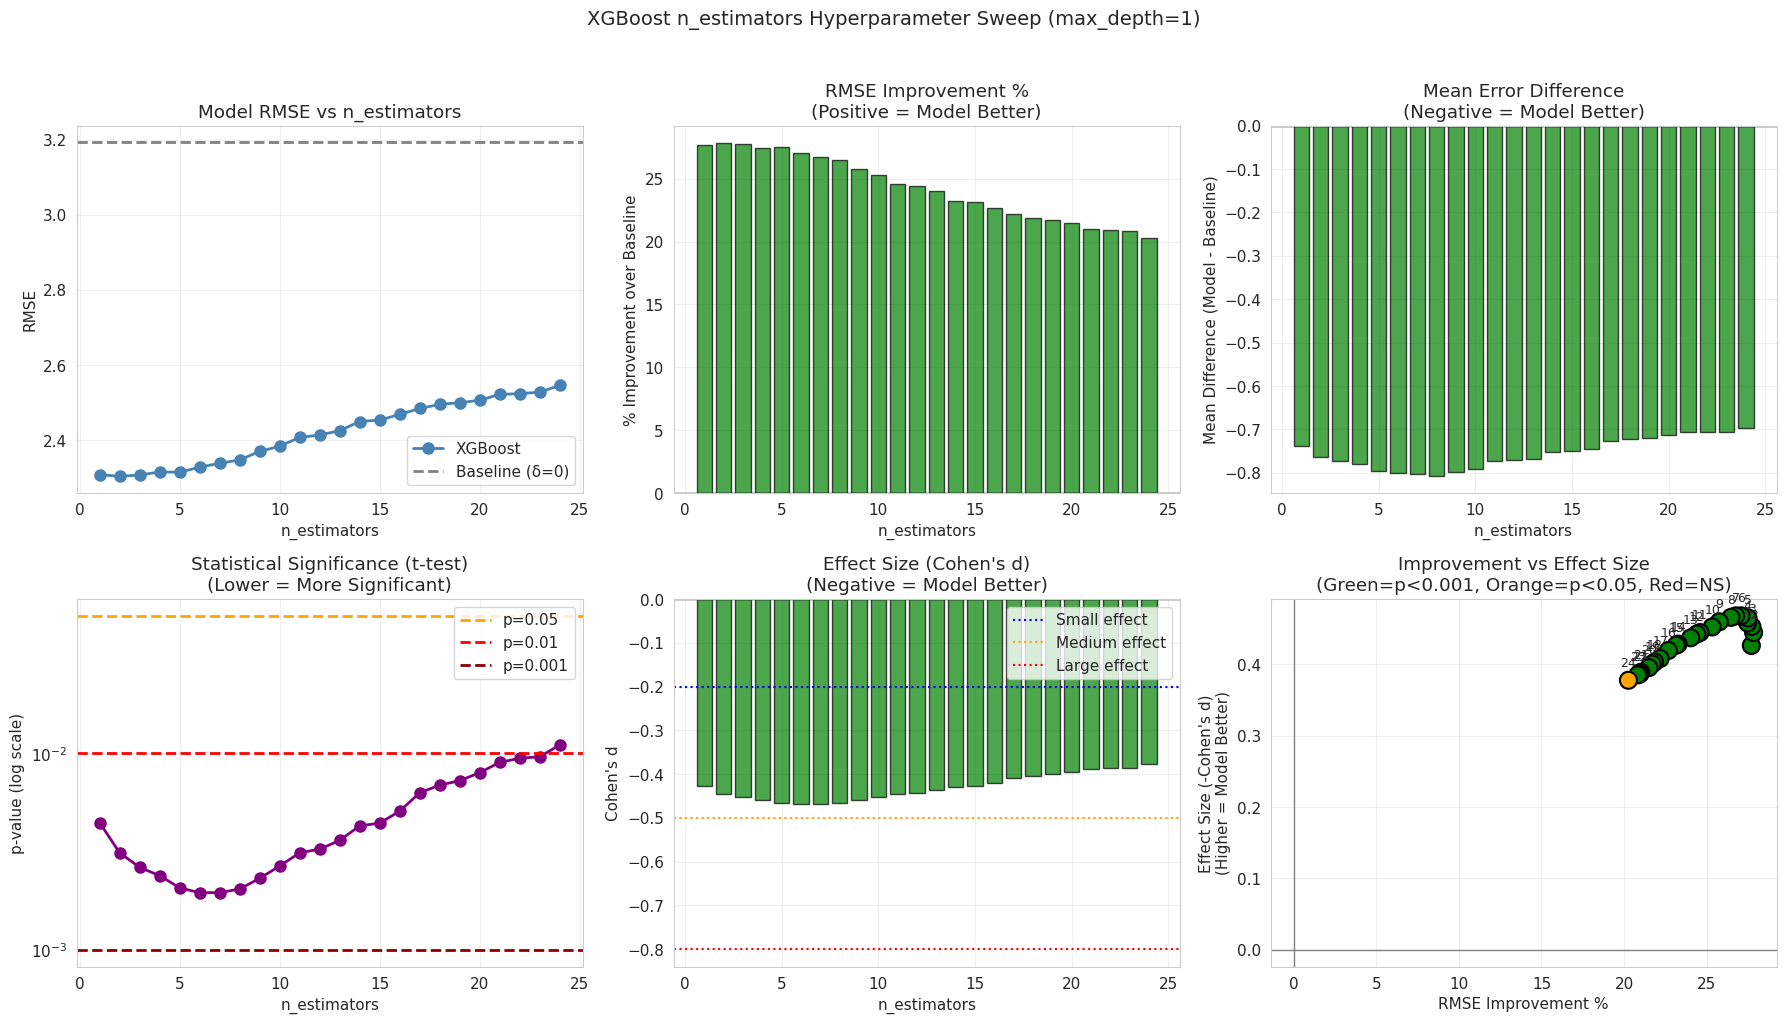


BEST CONFIGURATION:
  n_estimators = 2
  RMSE Improvement: 27.84%
  Mean Diff: -0.7634 (Model BETTER)
  p-value: 0.0031
  Cohen's d: -0.445


In [11]:
# ============================================
# PLOT: n_estimators SWEEP RESULTS
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

n_est_vals = sweep_results_df['n_estimators'].values

# 1. RMSE comparison
ax = axes[0, 0]
ax.plot(n_est_vals, sweep_results_df['model_rmse'], 'o-', color='steelblue', 
        linewidth=2, markersize=8, label='XGBoost')
ax.axhline(sweep_results_df['baseline_rmse'].iloc[0], color='gray', linestyle='--', 
           linewidth=2, label='Baseline (δ=0)')
ax.set_xlabel('n_estimators')
ax.set_ylabel('RMSE')
ax.set_title('Model RMSE vs n_estimators')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. RMSE Improvement %
ax = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in sweep_results_df['rmse_improvement_%']]
ax.bar(n_est_vals, sweep_results_df['rmse_improvement_%'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('n_estimators')
ax.set_ylabel('% Improvement over Baseline')
ax.set_title('RMSE Improvement %\n(Positive = Model Better)')
ax.grid(True, alpha=0.3)

# 3. Mean Difference (model - baseline)
ax = axes[0, 2]
colors = ['green' if x < 0 else 'red' for x in sweep_results_df['mean_diff']]
ax.bar(n_est_vals, sweep_results_df['mean_diff'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean Difference (Model - Baseline)')
ax.set_title('Mean Error Difference\n(Negative = Model Better)')
ax.grid(True, alpha=0.3)

# 4. P-value (t-test) - log scale
ax = axes[1, 0]
ax.semilogy(n_est_vals, sweep_results_df['p_value_ttest'], 'o-', color='purple', 
            linewidth=2, markersize=8)
ax.axhline(0.05, color='orange', linestyle='--', linewidth=2, label='p=0.05')
ax.axhline(0.01, color='red', linestyle='--', linewidth=2, label='p=0.01')
ax.axhline(0.001, color='darkred', linestyle='--', linewidth=2, label='p=0.001')
ax.set_xlabel('n_estimators')
ax.set_ylabel('p-value (log scale)')
ax.set_title('Statistical Significance (t-test)\n(Lower = More Significant)')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Cohen's d (effect size)
ax = axes[1, 1]
colors = ['green' if x < 0 else 'red' for x in sweep_results_df['cohens_d']]
ax.bar(n_est_vals, sweep_results_df['cohens_d'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(-0.2, color='blue', linestyle=':', linewidth=1.5, label='Small effect')
ax.axhline(-0.5, color='orange', linestyle=':', linewidth=1.5, label='Medium effect')
ax.axhline(-0.8, color='red', linestyle=':', linewidth=1.5, label='Large effect')
ax.set_xlabel('n_estimators')
ax.set_ylabel("Cohen's d")
ax.set_title("Effect Size (Cohen's d)\n(Negative = Model Better)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 6. Combined: Improvement vs Significance
ax = axes[1, 2]
# Color by significance level
sig_colors = []
for p in sweep_results_df['p_value_ttest']:
    if p < 0.001:
        sig_colors.append('darkgreen')
    elif p < 0.01:
        sig_colors.append('green')
    elif p < 0.05:
        sig_colors.append('orange')
    else:
        sig_colors.append('red')

scatter = ax.scatter(sweep_results_df['rmse_improvement_%'], -sweep_results_df['cohens_d'],
                     c=sig_colors, s=150, edgecolor='black', linewidth=1.5)

# Add n_estimators labels
for i, n_est in enumerate(n_est_vals):
    ax.annotate(str(n_est), (sweep_results_df['rmse_improvement_%'].iloc[i], 
                             -sweep_results_df['cohens_d'].iloc[i]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.axhline(0, color='gray', linestyle='-', linewidth=1)
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('RMSE Improvement %')
ax.set_ylabel("Effect Size (-Cohen's d)\n(Higher = Model Better)")
ax.set_title('Improvement vs Effect Size\n(Green=p<0.001, Orange=p<0.05, Red=NS)')
ax.grid(True, alpha=0.3)

plt.suptitle('XGBoost n_estimators Hyperparameter Sweep (max_depth=1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print best configuration
best_idx = sweep_results_df['rmse_improvement_%'].idxmax()
best_row = sweep_results_df.loc[best_idx]
print(f"\n{'='*60}")
print(f"BEST CONFIGURATION:")
print(f"  n_estimators = {int(best_row['n_estimators'])}")
print(f"  RMSE Improvement: {best_row['rmse_improvement_%']:.2f}%")
print(f"  Mean Diff: {best_row['mean_diff']:.4f} ({best_row['direction']})")
print(f"  p-value: {best_row['p_value_ttest']:.4f}")
print(f"  Cohen's d: {best_row['cohens_d']:.3f}")
print(f"{'='*60}")

## 5. Visualizations

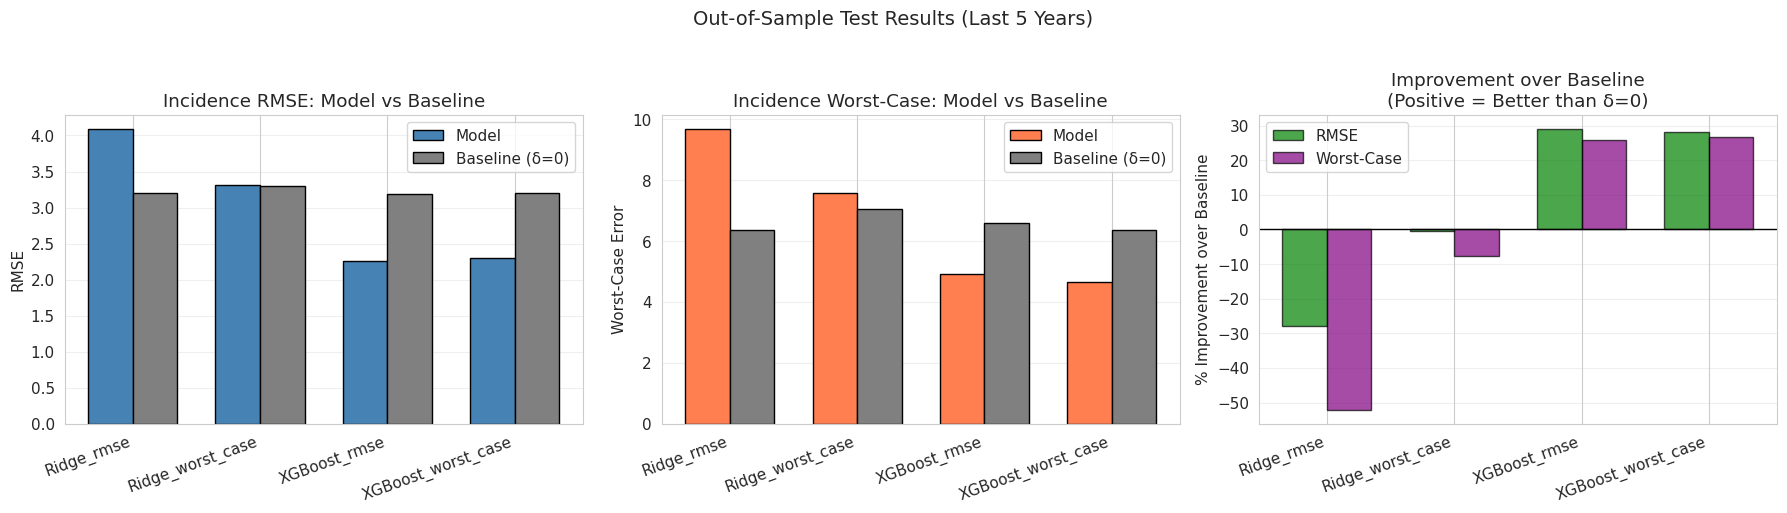

In [12]:
# Plot 1: Model vs Baseline comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(selections))
width = 0.35

# RMSE
ax = axes[0]
model_vals = [improvement_df[improvement_df['selection'] == s]['model_rmse'].values[0] for s in selections]
baseline_vals = [improvement_df[improvement_df['selection'] == s]['baseline_rmse'].values[0] for s in selections]
ax.bar(x - width/2, model_vals, width, label='Model', color='steelblue', edgecolor='black')
ax.bar(x + width/2, baseline_vals, width, label='Baseline (δ=0)', color='gray', edgecolor='black')
ax.set_ylabel('RMSE')
ax.set_title('Incidence RMSE: Model vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(selections, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Worst-Case
ax = axes[1]
model_vals = [improvement_df[improvement_df['selection'] == s]['model_worst_case'].values[0] for s in selections]
baseline_vals = [improvement_df[improvement_df['selection'] == s]['baseline_worst_case'].values[0] for s in selections]
ax.bar(x - width/2, model_vals, width, label='Model', color='coral', edgecolor='black')
ax.bar(x + width/2, baseline_vals, width, label='Baseline (δ=0)', color='gray', edgecolor='black')
ax.set_ylabel('Worst-Case Error')
ax.set_title('Incidence Worst-Case: Model vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(selections, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Improvement %
ax = axes[2]
rmse_imp = improvement_df['rmse_improvement_%'].values
worst_imp = improvement_df['worst_case_improvement_%'].values
ax.bar(x - width/2, rmse_imp, width, label='RMSE', color='green', edgecolor='black', alpha=0.7)
ax.bar(x + width/2, worst_imp, width, label='Worst-Case', color='purple', edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('% Improvement over Baseline')
ax.set_title('Improvement over Baseline\n(Positive = Better than δ=0)')
ax.set_xticks(x)
ax.set_xticklabels(selections, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Out-of-Sample Test Results (Last {n_test_years} Years)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

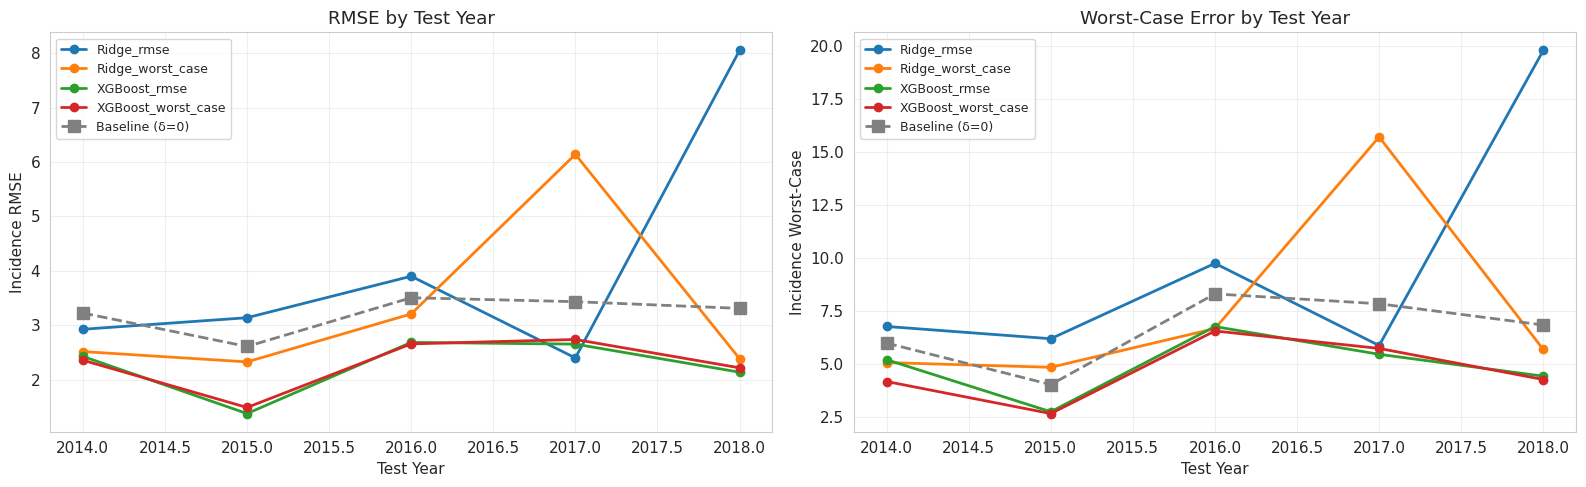

In [13]:
# Plot 2: Performance by test year
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE by year
ax = axes[0]
for selection in selections:
    sel_data = test_results_df[test_results_df['selection'] == selection]
    ax.plot(sel_data['test_year'], sel_data['incidence_rmse'], 'o-', label=selection, linewidth=2, markersize=6)

# Baseline
baseline_by_year = test_results_df.groupby('test_year')['baseline_rmse'].mean()
ax.plot(baseline_by_year.index, baseline_by_year.values, 's--', color='gray', linewidth=2, 
        markersize=8, label='Baseline (δ=0)')
ax.set_xlabel('Test Year')
ax.set_ylabel('Incidence RMSE')
ax.set_title('RMSE by Test Year')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Worst-case by year
ax = axes[1]
for selection in selections:
    sel_data = test_results_df[test_results_df['selection'] == selection]
    ax.plot(sel_data['test_year'], sel_data['incidence_worst_case'], 'o-', label=selection, linewidth=2, markersize=6)

baseline_by_year = test_results_df.groupby('test_year')['baseline_worst_case'].mean()
ax.plot(baseline_by_year.index, baseline_by_year.values, 's--', color='gray', linewidth=2, 
        markersize=8, label='Baseline (δ=0)')
ax.set_xlabel('Test Year')
ax.set_ylabel('Incidence Worst-Case')
ax.set_title('Worst-Case Error by Test Year')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

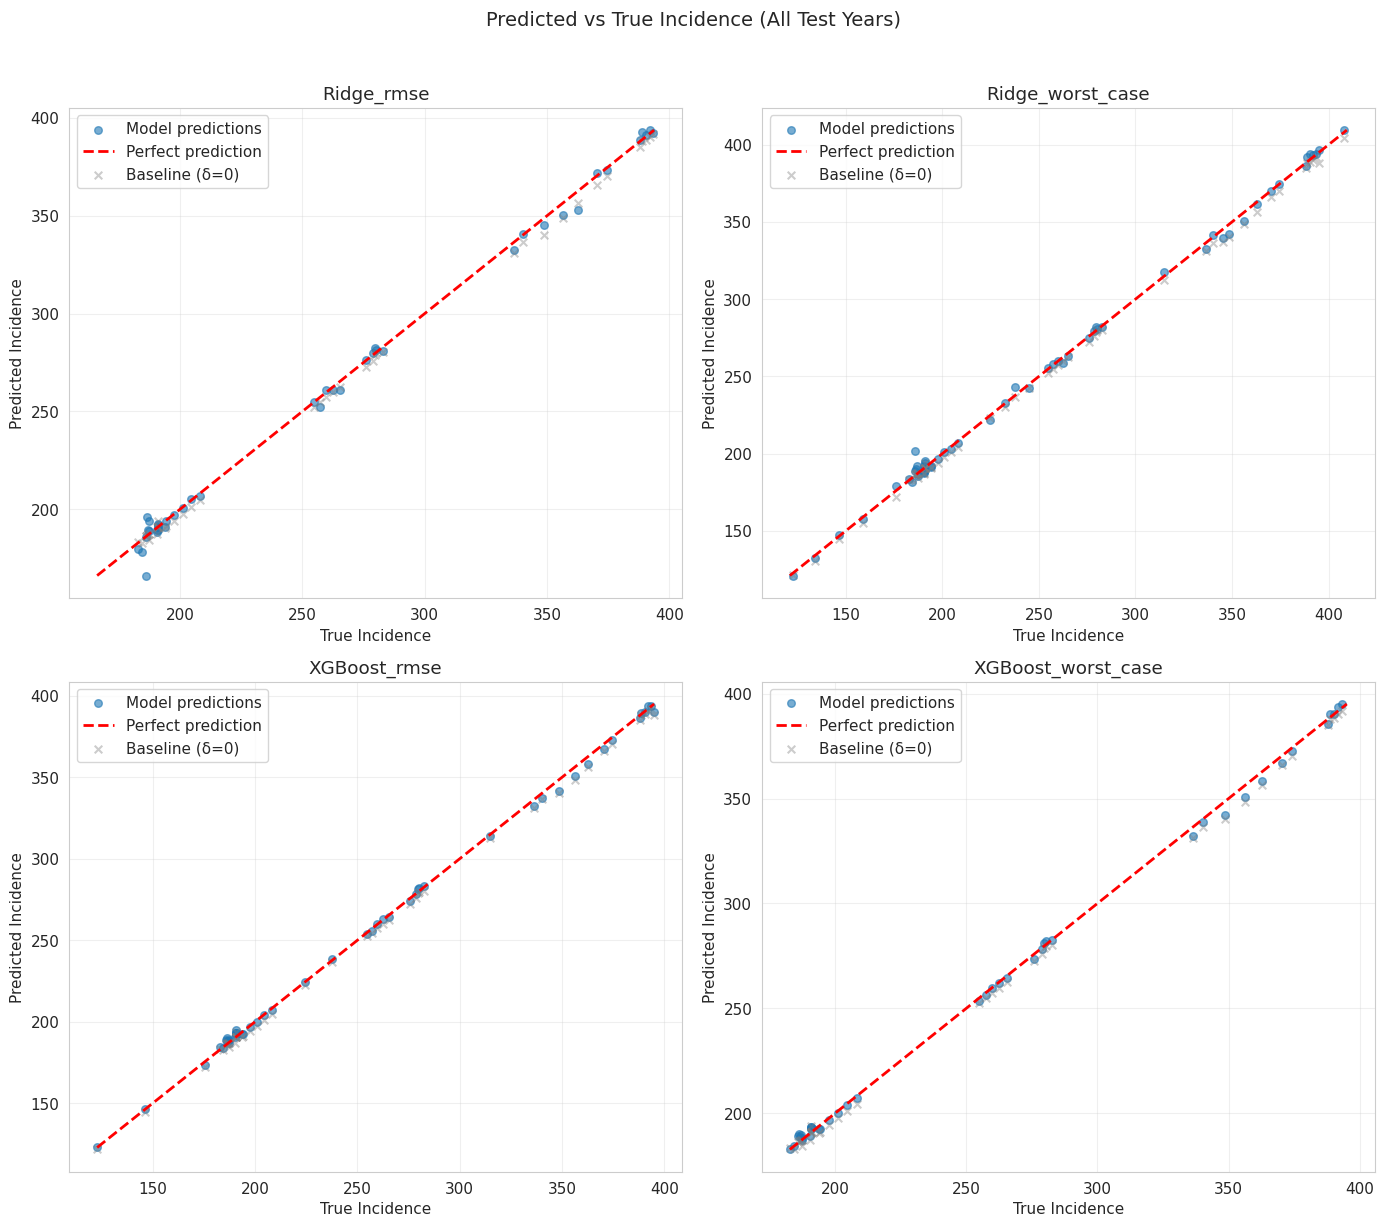

In [14]:
# Plot 3: Prediction scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, selection in enumerate(selections):
    ax = axes[idx // 2, idx % 2]
    
    sel_preds = predictions_df[predictions_df['selection'] == selection]
    
    # Model predictions
    ax.scatter(sel_preds['incidence_true'], sel_preds['incidence_pred'], 
               alpha=0.6, label='Model predictions', s=30)
    
    # Perfect prediction line
    min_val = min(sel_preds['incidence_true'].min(), sel_preds['incidence_pred'].min())
    max_val = max(sel_preds['incidence_true'].max(), sel_preds['incidence_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    # Baseline predictions
    ax.scatter(sel_preds['incidence_true'], sel_preds['baseline_pred'], 
               alpha=0.4, marker='x', color='gray', label='Baseline (δ=0)', s=30)
    
    ax.set_xlabel('True Incidence')
    ax.set_ylabel('Predicted Incidence')
    ax.set_title(f'{selection}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs True Incidence (All Test Years)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Error Analysis by Country

In [15]:
# Find worst predicted countries
print("=" * 80)
print("WORST PREDICTIONS BY COUNTRY")
print("=" * 80)

# Aggregate errors by country
country_errors = predictions_df.groupby('country').agg({
    'error': lambda x: np.sqrt(np.mean(x**2)),  # RMSE
    'baseline_error': lambda x: np.sqrt(np.mean(x**2)),
}).rename(columns={'error': 'model_rmse', 'baseline_error': 'baseline_rmse'})

country_errors['improvement'] = 100 * (country_errors['baseline_rmse'] - country_errors['model_rmse']) / country_errors['baseline_rmse']
country_errors = country_errors.sort_values('model_rmse', ascending=False)

print("\nTop 10 worst countries (highest RMSE):")
display(country_errors.head(10).round(4))

print("\nTop 10 best countries (lowest RMSE):")
display(country_errors.tail(10).round(4))

print("\nCountries where baseline beats model (negative improvement):")
worse_than_baseline = country_errors[country_errors['improvement'] < 0]
print(f"  {len(worse_than_baseline)} countries where model is worse than baseline")
if len(worse_than_baseline) > 0:
    display(worse_than_baseline.sort_values('improvement').head(10).round(4))

WORST PREDICTIONS BY COUNTRY

Top 10 worst countries (highest RMSE):


,model_rmse,baseline_rmse,improvement
country,,,
NLD,6.7104,0.3044,-2104.1600
DEU,4.8989,6.5343,25.0269
DNK,3.6791,5.2590,30.0410
ITA,3.2479,5.6698,42.7163
AUS,3.2409,1.5850,-104.4762
KAZ,2.8976,3.7895,23.5373
UKR,2.2114,1.3566,-63.0084
RUS,2.1996,2.5773,14.6565
GBR,1.9757,1.9030,-3.8169



Top 10 best countries (lowest RMSE):


,model_rmse,baseline_rmse,improvement
country,,,
UKR,2.2114,1.3566,-63.0084
RUS,2.1996,2.5773,14.6565
GBR,1.9757,1.9030,-3.8169
ROU,1.9175,2.6027,26.3261
USA,1.8666,4.2451,56.0298
POL,1.5582,1.8697,16.6613
CHN,1.4416,2.3664,39.0797
IDN,1.3138,2.0257,35.1458
IND,1.0474,3.3845,69.0541



Countries where baseline beats model (negative improvement):
  4 countries where model is worse than baseline


,model_rmse,baseline_rmse,improvement
country,,,
NLD,6.7104,0.3044,-2104.1600
AUS,3.2409,1.5850,-104.4762
UKR,2.2114,1.3566,-63.0084
GBR,1.9757,1.9030,-3.8169


## 7. Summary and Conclusions

In [16]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\nTest Configuration:")
print(f"  Test years: {test_years}")
print(f"  Total predictions: {len(predictions_df)}")

print(f"\nOverall Results:")
for _, row in improvement_df.iterrows():
    status = "✓" if row['rmse_improvement_%'] > 0 else "✗"
    print(f"  {status} {row['selection']}:")
    print(f"      RMSE: {row['model_rmse']:.4f} vs baseline {row['baseline_rmse']:.4f} ({row['rmse_improvement_%']:+.1f}%)")
    print(f"      Worst: {row['model_worst_case']:.4f} vs baseline {row['baseline_worst_case']:.4f} ({row['worst_case_improvement_%']:+.1f}%)")

# Best overall
best_rmse_idx = improvement_df['rmse_improvement_%'].idxmax()
best_rmse = improvement_df.loc[best_rmse_idx]

best_worst_idx = improvement_df['worst_case_improvement_%'].idxmax()
best_worst = improvement_df.loc[best_worst_idx]

print(f"\n" + "─" * 60)
print(f"BEST MODELS:")
print(f"  For RMSE: {best_rmse['selection']} ({best_rmse['rmse_improvement_%']:+.1f}% vs baseline)")
print(f"  For Worst-Case: {best_worst['selection']} ({best_worst['worst_case_improvement_%']:+.1f}% vs baseline)")

# Overall verdict
avg_improvement = improvement_df['rmse_improvement_%'].mean()
print(f"\n" + "─" * 60)
if avg_improvement > 5:
    print(f"✓ VERDICT: Models show meaningful improvement over baseline ({avg_improvement:.1f}% avg)")
elif avg_improvement > 0:
    print(f"~ VERDICT: Models show marginal improvement over baseline ({avg_improvement:.1f}% avg)")
else:
    print(f"✗ VERDICT: Models do NOT beat baseline - likely overfitting ({avg_improvement:.1f}% avg)")

FINAL SUMMARY

Test Configuration:
  Test years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
  Total predictions: 189

Overall Results:
  ✗ Ridge_rmse:
      RMSE: 4.0846 vs baseline 3.1950 (-27.8%)
      Worst: 9.6654 vs baseline 6.3546 (-52.1%)
  ✗ Ridge_worst_case:
      RMSE: 3.3183 vs baseline 3.3002 (-0.5%)
      Worst: 7.5840 vs baseline 7.0384 (-7.8%)
  ✓ XGBoost_rmse:
      RMSE: 2.2600 vs baseline 3.1875 (+29.1%)
      Worst: 4.9033 vs baseline 6.5995 (+25.7%)
  ✓ XGBoost_worst_case:
      RMSE: 2.2958 vs baseline 3.1950 (+28.1%)
      Worst: 4.6627 vs baseline 6.3546 (+26.6%)

────────────────────────────────────────────────────────────
BEST MODELS:
  For RMSE: XGBoost_rmse (+29.1% vs baseline)
  For Worst-Case: XGBoost_worst_case (+26.6% vs baseline)

────────────────────────────────────────────────────────────
✓ VERDICT: Models show meaningful improvement over baseline (7.2% avg)


In [17]:
# Export results
test_results_df.to_csv(os.path.join(OUTPUT_DIR, 'test_results_summary.csv'), index=False)
predictions_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions_detailed.csv'), index=False)
improvement_df.to_csv(os.path.join(OUTPUT_DIR, 'test_improvement_over_baseline.csv'), index=False)

print("✓ Results exported to:")
print(f"  - {OUTPUT_DIR}/test_results_summary.csv")
print(f"  - {OUTPUT_DIR}/test_predictions_detailed.csv")
print(f"  - {OUTPUT_DIR}/test_improvement_over_baseline.csv")

✓ Results exported to:
  - outputs/test_results_summary.csv
  - outputs/test_predictions_detailed.csv
  - outputs/test_improvement_over_baseline.csv


In [18]:
# === DECISION PATHS FOR EACH TREE PER TEST YEAR ===
# This cell shows how each tree in the XGBoost model makes decisions for each test year (no plotting).
# It prints the decision path and leaf values for each test sample in the test set, per tree.

from xgboost import XGBRegressor, Booster
import json

for test_year in test_years:
    train_year = test_year - 1
    selection_key = 'XGBoost_rmse'
    if (train_year, selection_key) not in features_by_year_selection:
        print(f"No XGBoost_rmse selection for train year {train_year}")
        continue
    selected_features = features_by_year_selection[(train_year, selection_key)]
    train_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, train_year, drop_na=False)
    test_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, test_year, drop_na=False)
    valid_features = [f for f in selected_features if f in train_df.columns and f in test_df.columns]
    train_df = train_df.dropna(subset=valid_features + ['target'])
    test_df = test_df.dropna(subset=valid_features + ['target'])
    if train_df.empty or test_df.empty:
        print(f"No data for year {test_year}")
        continue
    X_train = train_df[valid_features].values
    y_train = train_df['target'].values
    X_test = test_df[valid_features].values
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = XGBRegressor(n_estimators=4, max_depth=1, learning_rate=0.1, random_state=42, verbosity=0)
    model.fit(X_train_scaled, y_train)
    booster: Booster = model.get_booster()
    print(f"\nTest year: {test_year}")
    print(f"  Number of trees: {booster.num_boosted_rounds()}")
    # For each test sample, print the leaf index for each tree
    leaf_indices = model.apply(X_test_scaled)
    for i, country in enumerate(test_df['Country Code'].values):
        print(f"    Country: {country}")
        print(f"      Leaf indices per tree: {leaf_indices[i]}")
    # Optionally, print the tree structure as text for reference
    print("  Tree structure (first tree):")
    print(booster.get_dump(with_stats=True)[0])
    print("  ... (use get_dump() for all trees if needed)")

  Target year 2013: 22 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013)])
  Built dataset: 16 countries, 704 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014)])
  Built dataset: 16 countries, 736 features

Test year: 2014
  Number of trees: 4
    Country: AUS
      Leaf indices per tree: [1. 1. 1. 1.]
  

In [19]:
# === DISTRIBUTION COMPARISON: true_deltas vs (train+test_deltas) ===
# This cell compares the distribution of true deltas (test set) vs all deltas (train+test)

# Collect all train+test deltas (target values) and true test deltas
all_deltas = []
true_test_deltas = []
for test_year in test_years:
    train_year = test_year - 1
    # Get train and test sets
    train_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, train_year, drop_na=False)
    test_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, test_year, drop_na=False)
    if not train_df.empty:
        all_deltas.extend(train_df['target'].dropna().values)
    if not test_df.empty:
        all_deltas.extend(test_df['target'].dropna().values)
        true_test_deltas.extend(test_df['target'].dropna().values)

all_deltas = np.array(all_deltas)
true_test_deltas = np.array(true_test_deltas)

print(f"All deltas (train+test) count: {len(all_deltas)}")
print(f"True test deltas count: {len(true_test_deltas)}")
print("\nSummary statistics:")
print("All deltas:")
print(pd.Series(all_deltas).describe())
print("\nTrue test deltas:")
print(pd.Series(true_test_deltas).describe())

# Optionally, show quantiles
print("\nQuantiles (all deltas):", np.quantile(all_deltas, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]))
print("Quantiles (true test deltas):", np.quantile(true_test_deltas, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]))

  Target year 2013: 22 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013)])
  Built dataset: 16 countries, 704 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014)])
  Built dataset: 16 countries, 736 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int6

  Target year 2013: 22 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013)])
  Built dataset: 16 countries, 704 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014)])
  Built dataset: 16 countries, 736 features
  Target year 2014: 23 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int6

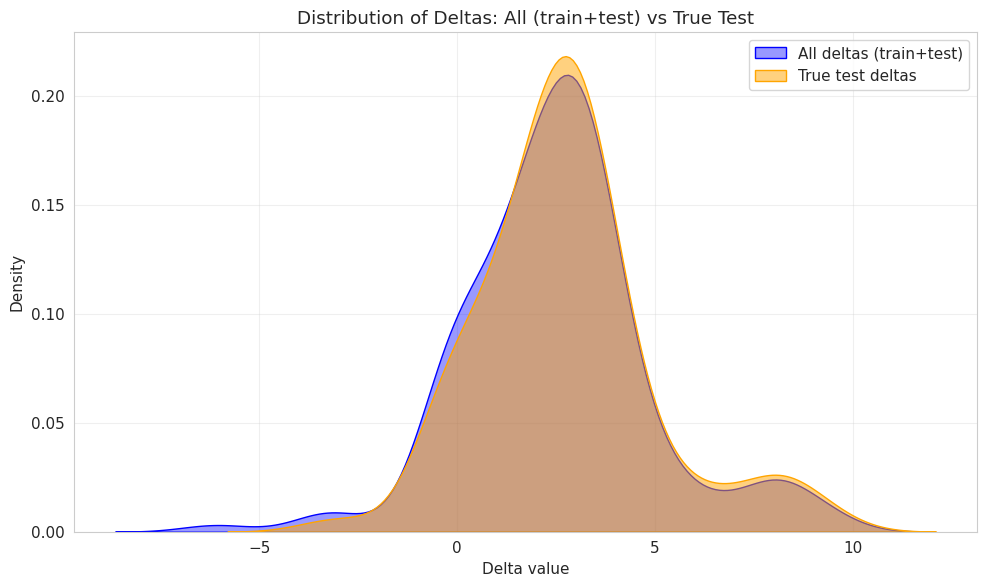

In [ ]:
# === FEATURE IMPORTANCE AND DELTA DISTRIBUTION PLOT ===
# 1. Show mean feature importance for XGBoost_rmse across all test years
# 2. Plot the distribution of true test deltas vs all (train+test) deltas on the same plot

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate feature importances for XGBoost_rmse
feature_importances = {}
for test_year in test_years:
    train_year = test_year - 1
    selection_key = 'XGBoost_rmse'
    if (train_year, selection_key) not in features_by_year_selection:
        continue
    selected_features = features_by_year_selection[(train_year, selection_key)]
    train_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, train_year, drop_na=False)
    test_df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, test_year, drop_na=False)
    valid_features = [f for f in selected_features if f in train_df.columns and f in test_df.columns]
    train_df = train_df.dropna(subset=valid_features + ['target'])
    if train_df.empty:
        continue
    X_train = train_df[valid_features].values
    y_train = train_df['target'].values
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    model = XGBRegressor(n_estimators=4, max_depth=1, learning_rate=0.1, random_state=42, verbosity=0)
    model.fit(X_train_scaled, y_train)
    for feat, imp in zip(valid_features, model.feature_importances_):
        feature_importances.setdefault(feat, []).append(imp)

# Compute mean importance
mean_importance = {feat: np.mean(imps) for feat, imps in feature_importances.items()}
# Sort by importance
sorted_feats = sorted(mean_importance.items(), key=lambda x: x[1], reverse=True)
print("Top features by mean XGBoost importance (across test years):")
for feat, imp in sorted_feats[:15]:
    print(f"  {feat}: {imp:.4f}")


  Target year 1991: 1 lag years available ([np.int64(1991)])
  Built dataset: 36 countries, 32 features
  Target year 1992: 2 lag years available ([np.int64(1991), np.int64(1992)])
  Built dataset: 36 countries, 64 features
  Target year 1993: 3 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993)])
  Built dataset: 37 countries, 96 features
  Target year 1994: 4 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994)])
  Built dataset: 37 countries, 128 features
  Target year 1995: 5 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995)])
  Built dataset: 37 countries, 160 features
  Target year 1996: 6 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996)])
  Built dataset: 37 countries, 192 features
  Target year 1997: 7 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(

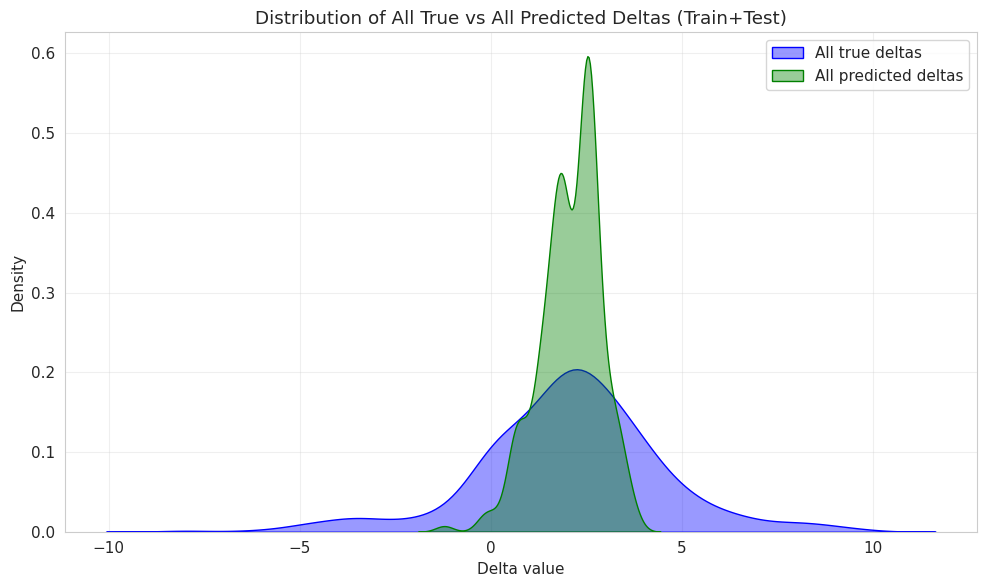

In [21]:
# === DISTRIBUTION: ALL TRUE DELTAS VS ALL PREDICTED DELTAS (TRAIN+TEST) ===
# This cell compares the distribution of all true deltas vs all predicted deltas (train+test) for XGBoost_rmse

all_true_deltas = []
all_pred_deltas = []
for year in sorted(all_target_years):
    # Use only years for which we have feature selection and can build train/test
    selection_key = 'XGBoost_rmse'
    if (year, selection_key) not in features_by_year_selection:
        continue
    selected_features = features_by_year_selection[(year, selection_key)]
    df, _, _ = build_stacked_delta_dataset(df_base, base_feature_cols, year, drop_na=False)
    valid_features = [f for f in selected_features if f in df.columns]
    df = df.dropna(subset=valid_features + ['target'])
    if df.empty:
        continue
    X = df[valid_features].values
    y = df['target'].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = XGBRegressor(n_estimators=4, max_depth=1, learning_rate=0.1, random_state=42, verbosity=0)
    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)
    all_true_deltas.extend(y)
    all_pred_deltas.extend(y_pred)

all_true_deltas = np.array(all_true_deltas)
all_pred_deltas = np.array(all_pred_deltas)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(all_true_deltas, label='All true deltas', fill=True, color='blue', alpha=0.4)
sns.kdeplot(all_pred_deltas, label='All predicted deltas', fill=True, color='green', alpha=0.4)
plt.xlabel('Delta value')
plt.ylabel('Density')
plt.title('Distribution of All True vs All Predicted Deltas (Train+Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()